X_train shape: (14241, 30, 18)


d:\RUL\DL\lib\site-packages\keras\src\layers\rnn\bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)   │ (None, 30, 256)        │       150,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        82,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 238,977 (933.50 KB)

 Trainable params: 238,977 (933.50 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
446/446 ━━━━━━━━━━━━━━━━━━━━ 16s 27ms/step - loss: 0.0993 - val_loss: 0.0838 - learning_rate: 0.0010
Epoch 2/100
446/446 ━━━━━━━━━━━━━━━━━━━━ 12s 27ms/step - loss: 0.0694 - val_loss: 0.0717 - learning_rate: 0.0010
Epoch 3/100
446/446 ━━━━━━━━━━━━━━━━━━━━ 12s 27ms/step - loss: 0.0565 - val_loss: 0.1006 - learning_rate: 0.0010
Epoch 4/100
446/446 ━━━━━━━━━━━━━━━━━━━━ 12s 27ms/step - loss: 0.0506 - val_loss: 0.1113 - learning_rate: 0.0010
Epoch 5/100
446/446 ━━━━━━━━━━━━━━━━━━━━ 13s 30ms/step - loss: 0.0464 - val_loss: 0.0680 - learning_rate: 0.0010
Epoch 6/100
446/446 ━━━━━━━━━━━━━━━━━━━━ 12s 27ms/step - loss: 0.0412 - val_loss: 0.0899 - learning_rate: 0.0010
Epoch 7/100
446/446 ━━━━━━━━━━━━━━━━━━━━ 12s 26ms/step - loss: 0.0367 - val_loss: 0.0689 - learning_rate: 0.0010
Epoch 8/100
446/446 ━━━━━━━━━━━━━━━━━━━━ 12s 27ms/step - loss: 0.0324 - val_loss: 0.0689 - learning_rate: 0.0010
Epoch 9/100
446/446 ━━━━━━━━━━━━━━━━━━━━ 12s 27ms/step - loss: 0.0303 - val_loss: 0.0711 - learn

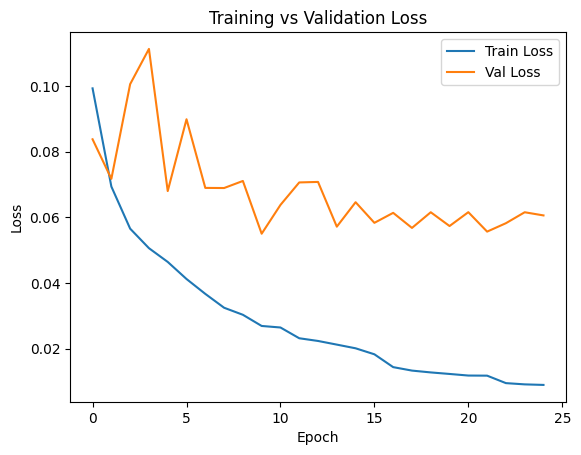

In [1]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.losses import Huber
from sklearn.metrics import mean_squared_error
import math
import matplotlib.pyplot as plt
import random

# -------------------------
# SEED
# -------------------------
seed = 42
np.random.seed(seed)
tf.random.set_seed(seed)
random.seed(seed)

# -------------------------
# LOAD DATA
# -------------------------
X_train = np.load("../data/processed/X_train.npy")
y_train = np.load("../data/processed/y_train.npy")

X_val = np.load("../data/processed/X_val.npy")
y_val = np.load("../data/processed/y_val.npy")

timesteps = X_train.shape[1]
features = X_train.shape[2]

print("X_train shape:", X_train.shape)

# -------------------------
# NORMALIZE TARGET
# -------------------------
y_train = y_train/ 125.0
y_val = y_val / 125.0

# -------------------------
# BUILD MODEL
# -------------------------
model = Sequential([
    Bidirectional(LSTM(128, return_sequences=True), input_shape=(timesteps, features)),
    Dropout(0.2),

    LSTM(64),
    Dropout(0.2),

    Dense(64, activation='relu'),
    Dense(32, activation='relu'),

    Dense(1)  # normalized output
])

model.compile(
    optimizer=Adam(learning_rate=0.001, clipnorm=1.0),
    loss='mae'
)

model.summary()

# -------------------------
# CALLBACKS
# -------------------------
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=6,
    min_lr=1e-5
)

# -------------------------
# TRAIN
# -------------------------
history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_data=(X_val,y_val),
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

# -------------------------
# PREDICT (DENORMALIZE)
# -------------------------
y_train_pred = model.predict(X_train)*125
y_val_pred = model.predict(X_val)*125

y_train_actual = y_train * 125  # ← denormalize the actuals too
y_val_actual = y_val * 125

train_rmse = math.sqrt(mean_squared_error(y_train_actual, y_train_pred))
val_rmse = math.sqrt(mean_squared_error(y_val_actual, y_val_pred))

print("\n=== FINAL RESULTS ===")
print("Val RMSE:", val_rmse)
print("Train rmse:",train_rmse)

# -------------------------
# PLOT
# -------------------------
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

In [2]:
# -------------------------
# LOAD TEST DATA
# -------------------------
X_test = np.load("../data/processed/X_test_final.npy")
rul_test = np.load("../data/processed/rul_test.npy")

# -------------------------
# PREDICT
# -------------------------
y_test_pred = model.predict(X_test).flatten()

# -------------------------
# RMSE
# -------------------------
y_test_pred = y_test_pred * 125.0
test_rmse = math.sqrt(mean_squared_error(rul_test, y_test_pred))

print("\n=== TEST RESULTS ===")
print("Test RMSE:", test_rmse)

# -------------------------
# SAMPLE PREDICTIONS
# -------------------------
for i in range(10):
    print(
        f"Actual: {rul_test[i]} | "
        f"Predicted: {round(y_test_pred[i], 2)}"
    )

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step

=== TEST RESULTS ===
Test RMSE: 29.01592790633491
Actual: [112.] | Predicted: 122.69999694824219
Actual: [98.] | Predicted: 123.4000015258789
Actual: [69.] | Predicted: 71.87999725341797
Actual: [82.] | Predicted: 89.05999755859375
Actual: [91.] | Predicted: 101.83999633789062
Actual: [93.] | Predicted: 89.41000366210938
Actual: [91.] | Predicted: 61.09000015258789
Actual: [95.] | Predicted: 35.810001373291016
Actual: [111.] | Predicted: 123.0
Actual: [96.] | Predicted: 36.209999084472656
